In [1]:
# Hyper-EZ Demo

## Clone required repositories
!git clone https://github.com/naikp13/hyper-ez.git && cd hyper-ez && pip install -r requirements.txt
!git clone https://github.com/naikp13/hyEnhance.git

Cloning into 'hyper-ez'...
remote: Enumerating objects: 104, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 104 (delta 62), reused 34 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (104/104), 938.08 KiB | 8.30 MiB/s, done.
Resolving deltas: 100% (62/62), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.2/208.2 kB 14.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-contrib-python
    Found existing installation: opencv-contrib-python 4.12.0.88
    Uninstalling opencv-contrib-python-4.12.0.88:
      Successfully uninstalled opencv-contrib-python-4.12.0.88
Cloning into 'hyEnhance'...
remote: Enumerating objects: 214, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 214 (delta 56), re

In [2]:
# Import required packages

from google.colab import drive
drive.mount("/content/drive/", force_remount = True)
import sys; sys.path.append('/content/hyper-ez')
from google.colab import files
from hyper_ez import *

Mounted at /content/drive/


**1. INPUT LOW RESOLUTION HYPERSPECTRAL**

In [3]:
# Upload hyperspectral image (.tif or .dat format and Georeferenced)
# e.g. - /content/drive/MyDrive/pansharpen/enmap_marinkas.tif

# Ideal dimensions for input hyperspectral scene to run on (free) google colab - 200 x 200 (~10 MB)

print("Upload your Low-Resolution Hyperspectral Image")

# Direct file path input
hsi_path = input("Enter path to your .tif file in the box: ")

Upload your Low-Resolution Hyperspectral Image
Enter path to your .tif file in the box: /content/drive/MyDrive/pansharpen/enmap_marinkas.tif


**2. INPUT DATE OF ACQUISITION**

In [4]:
# Get target date (YYYY-MM-DD)
# e.g. - 2024-07-20
target_date = input("Enter the date of acquisition  (YYYY-MM-DD) in the box: ")

Enter the date of acquisition  (YYYY-MM-DD) in the box: 2024-07-20


**3. INITIALIZE PROCESSORS**

In [5]:
# Initialize processors
setup_matplotlib_style()
data_acq = SatelliteDataAcquisition()
geo_proc = GeospatialProcessor()
hsi_proc = HyperspectralProcessor()
visualizer = HyperspectralVisualizer()

# Extract metadata and search satellite data
roi, bounds, crs, res = geo_proc.extract_spatial_metadata(hsi_path)
sentinel_item = data_acq.search_sentinel2_data(roi, target_date)
print(f"Found Sentinel-2: {sentinel_item.id} ({sentinel_item.properties['eo:cloud_cover']}% clouds)")

Found Sentinel-2: S2A_33JYJ_20240716_0_L2A (0.394939% clouds)


**4. INITIALIZE THE ENHANCEMENT PROCESS**

In [6]:
# Process and enhance
bands = geo_proc.process_sentinel2_bands(sentinel_item, bounds, crs)
geo_proc.stack_bands_to_multiband(bands, 'sentinel.tif')
esri_path = hsi_proc.acquire_high_resolution_imagery(bounds, crs)
hsi_enhanced = hsi_proc.enhance_hyperspectral_image('sentinel.tif', hsi_path)
hsi_proc.save_enhanced_data(hsi_enhanced, 'sentinel.tif', 'temp_enhanced.tif')
hsi_super = hsi_proc.enhance_hyperspectral_image(esri_path, 'temp_enhanced.tif')

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
Processing patches: 100%|██████████| 41830/41830 [00:59<00:00, 703.76it/s]


**5. DISPLAY RESULTS**

In [7]:
from hyEnhance.src import *
hsi = HSIDataLoader.load_image(hsi_path)

In [15]:
# Check eliminated band-numbers from enhanced data
import numpy as np
valid_bands = np.isnan(hsi).mean(axis=(0, 1)) <= 0.5
eliminated_bands = np.where(~valid_bands)[0]
print(eliminated_bands)

[130 131 132 133 134]


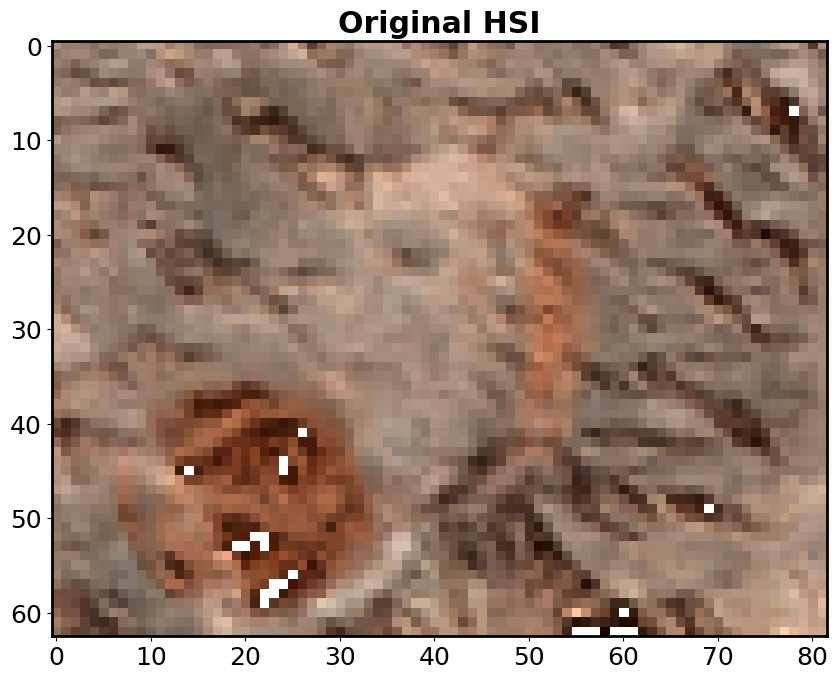

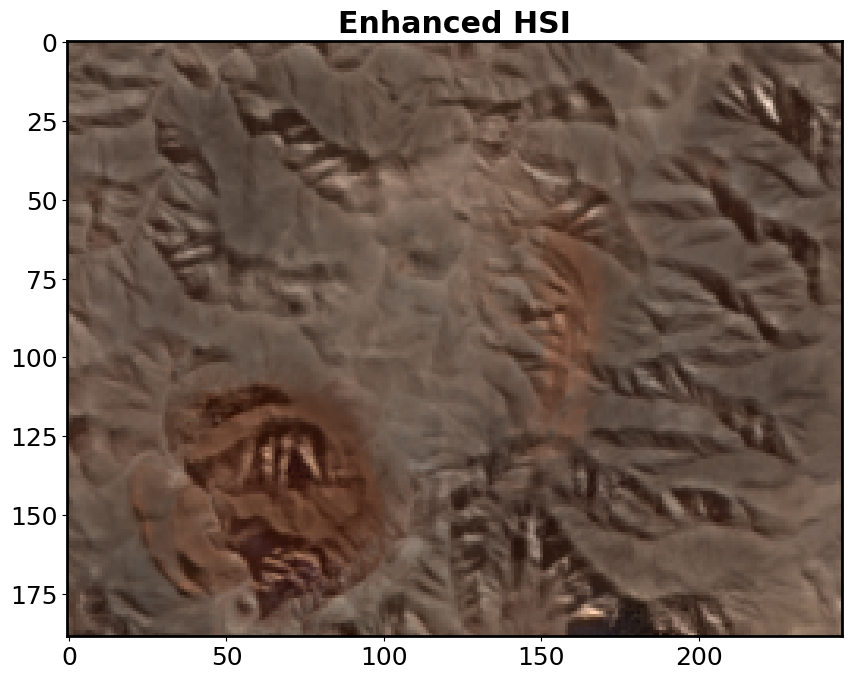

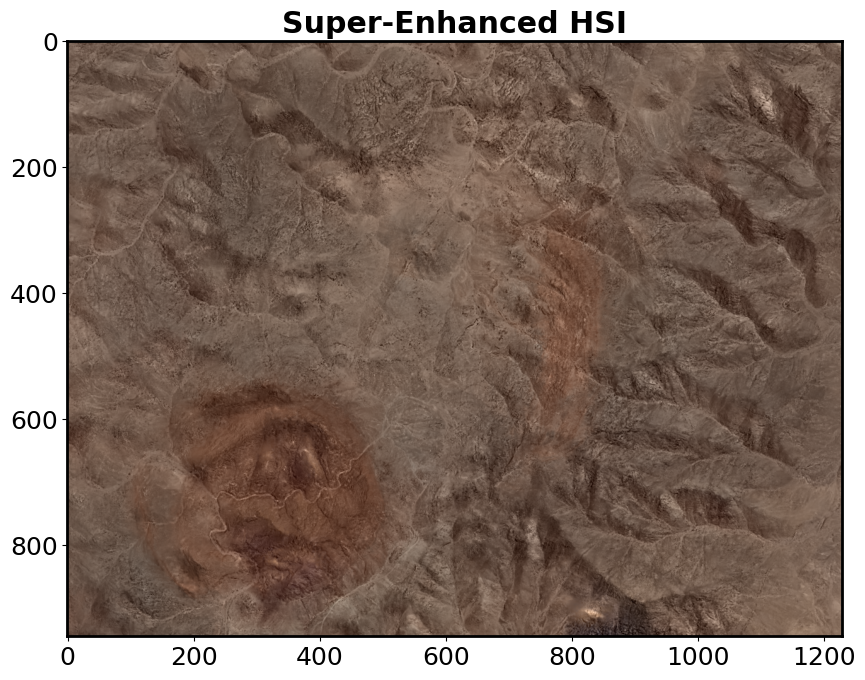

In [8]:
# Display results
visualizer.display_false_color_composite(hsi, "Original HSI")
visualizer.display_false_color_composite(hsi_enhanced, "Enhanced HSI")
visualizer.display_false_color_composite(hsi_super, "Super-Enhanced HSI")

In [9]:
print(f"Original: {hsi.shape}",f"Enhanced: {hsi_enhanced.shape}", f"Super-Enhanced: {hsi_super.shape}")

Original: (63, 82, 224) Enhanced: (189, 246, 219) Super-Enhanced: (945, 1230, 219)


In [10]:
hsi_proc.save_enhanced_data(hsi_enhanced, 'sentinel.tif', 'enhanced.tif')
hsi_proc.save_enhanced_data(hsi_super, esri_path, 'super_enhanced.tif')

In [11]:
# Download the enhanced and super-enhanced files to local drive
files.download('enhanced.tif')
files.download('super_enhanced.tif')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# Download the enhanced and super-enhanced files to google drive

import os, shutil

DRIVE_DIR = "/content/drive/MyDrive/hyper_ez_outputs"
os.makedirs(DRIVE_DIR, exist_ok=True)

enh_drive_path   = os.path.join(DRIVE_DIR, f"enhanced.tif")
super_enh_drive_path = os.path.join(DRIVE_DIR, f"super_enhanced.tif")

shutil.copy2("enhanced.tif", enh_drive_path)
shutil.copy2("super_enhanced.tif", super_enh_drive_path)

print("Saved to Google Drive:")
print(" -", enh_drive_path)
print(" -", super_enh_drive_path)

Saved to Google Drive:
 - /content/drive/MyDrive/hyper_ez_outputs/enhanced.tif
 - /content/drive/MyDrive/hyper_ez_outputs/super_enhanced.tif
